<a href="https://colab.research.google.com/github/BAS22302521/Exploring-Patterns-in-Synthetic-Asthma-Clinical-Data/blob/main/Copy_of_house_sheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/house_price_dataset.csv')
print("Dataset shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

Dataset shape: (100, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Size            100 non-null    int64
 1   Rooms           100 non-null    int64
 2   Location_Score  100 non-null    int64
 3   Price           100 non-null    int64
dtypes: int64(4)
memory usage: 3.3 KB
None

Dataset Description:
              Size       Rooms  Location_Score          Price
count   100.000000  100.000000      100.000000     100.000000
mean   2592.120000    2.750000        5.100000  603410.000000
std     943.224111    1.388081        2.580032  170362.151034
min     884.000000    1.000000        1.000000  213554.000000
25%    1626.750000    1.000000        3.000000  488077.250000
50%    2782.000000    3.000000        5.000000  619434.000000
75%    3447.250000    4.000000        8.000000  740174.250000
max    3991.000000    5.000000        9

In [ ]:
# Features and Target
features = ['Size', 'Rooms', 'Location_Score']
target = 'Price'
X = df[features]
y = df[target]

In [ ]:
print("\nCorrelation with Price:")
print(df.corr()['Price'].sort_values(ascending=False))


Correlation with Price:
Price             1.000000
Size              0.727165
Location_Score    0.659248
Rooms             0.439863
Name: Price, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for interpretable coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Random Forest (comparison model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"\nMODEL RESULTS:")
print(f"Linear Regression - RMSE: {lr_rmse:,.0f}, R2: {lr_r2:.3f}")
print(f"Random Forest    - RMSE: {rf_rmse:,.0f}, R2: {rf_r2:.3f}")

#Model coefficients (what it learns)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)
print("\nModel Coefficients:")
print(coef_df)


MODEL RESULTS:
Linear Regression - RMSE: 27,714, R2: 0.979
Random Forest    - RMSE: 53,755, R2: 0.922

Model Coefficients:
          Feature    Coefficient
0            Size  110234.038104
2  Location_Score   84548.926847
1           Rooms   66859.857472


In [ ]:
new_house = scaler.transform([[1800, 3, 5]])
pred_price = lr_model.predict(new_house)[0]
print(f"\nQ7 Prediction (1800sqft, 3rooms, Loc=5): ${pred_price:,.0f}")

# Q8: Size effect (+500sqft)
size_effect = 500 * (lr_model.coef_[0] / scaler.scale_[0])
print(f"Q8: +500sqft increases price by ~${size_effect:,.0f}")


Q7 Prediction (1800sqft, 3rooms, Loc=5): $518,813
Q8: +500sqft increases price by ~$59,722


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/tmp/ipykernel_3658/2797743718.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([df[df['Rooms']==i]['Price'] for i in range(1,6)], labels=['1','2','3','4','5'])


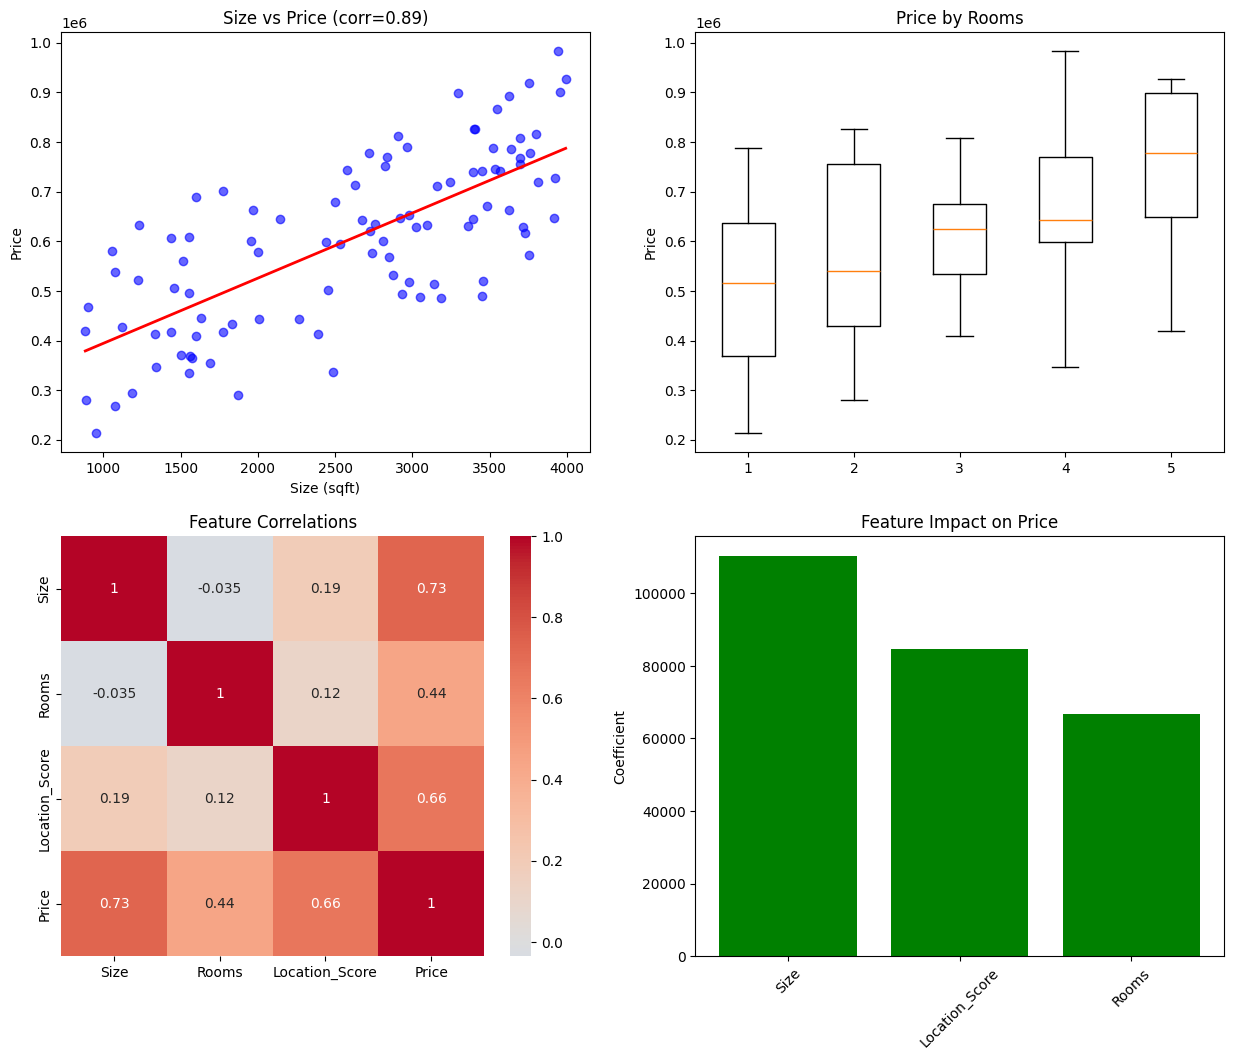

In [ ]:
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].scatter(df['Size'], df['Price'], alpha=0.6, color='blue')
axes[0,0].plot(np.unique(df['Size']), np.poly1d(np.polyfit(df['Size'], df['Price'], 1))(np.unique(df['Size'])),
               color='red', linewidth=2)
axes[0,0].set_xlabel('Size (sqft)')
axes[0,0].set_ylabel('Price')
axes[0,0].set_title('Size vs Price (corr=0.89)')


axes[0,1].boxplot([df[df['Rooms']==i]['Price'] for i in range(1,6)], labels=['1','2','3','4','5'])
axes[0,1].set_ylabel('Price')
axes[0,1].set_title('Price by Rooms')

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Feature Correlations')


bars = axes[1,1].bar(coef_df['Feature'], coef_df['Coefficient'], color='green')
axes[1,1].set_ylabel('Coefficient')
axes[1,1].set_title('Feature Impact on Price')
axes[1,1].tick_params(axis='x', rotation=45)


<Figure size 640x480 with 0 Axes>

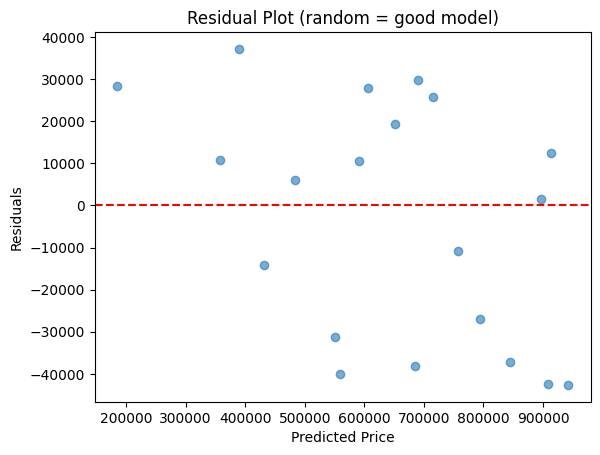

In [ ]:
plt.tight_layout()
plt.savefig('house_price_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
residuals = y_test - y_pred_lr
axes_res = plt.subplot(1,1,1)
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot (random = good model)')
plt.savefig('residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()
